# Interpretación del modelo y conclusiones de negocio

## Objetivo del notebook

El objetivo de este notebook es analizar e interpretar el modelo de clasificación seleccionado tras la fase de optimización, evaluando su rendimiento sobre el conjunto de prueba e identificando los factores que más influyen en la predicción del abandono de clientes.

Además, se traducirán los resultados obtenidos en conclusiones de negocio, proponiendo posibles acciones que permitan reducir la tasa de abandono y mejorar la retención de clientes.

# 1. Carga de librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Modelo seleccionado
from xgboost import XGBClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

# Visualización
import matplotlib.pyplot as plt

# 2. Carga de datos

## Objetivo

En este apartado se cargan los conjuntos de entrenamiento y prueba preprocesados generados durante el Notebook 3.

Además, se convierte la variable objetivo a formato numérico para entrenar el modelo seleccionado utilizando el mismo flujo de trabajo empleado durante la fase de optimización.

In [2]:
# Carga de los conjuntos de entrenamiento y prueba

X_train = pd.read_csv("../data/processed/X_train_preprocesado.csv")
X_test = pd.read_csv("../data/processed/X_test_preprocesado.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

In [3]:
# Conversión de la variable objetivo

y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [4]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (5634, 45)
X_test: (1409, 45)
y_train: (5634,)
y_test: (1409,)


# 3. Entrenamiento del modelo final

## Objetivo

En lugar de cargar un modelo previamente entrenado, se vuelve a entrenar **XGBoost** utilizando la mejor configuración obtenida durante el proceso de optimización.

De esta forma, el notebook es completamente reproducible e independiente del Notebook 5.

In [5]:
# Entrenamiento del modelo final

modelo_final = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

modelo_final.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# 4. Evaluación del modelo

## Objetivo

En este apartado se evalúa el rendimiento del modelo seleccionado sobre el conjunto de prueba mediante diferentes métricas de clasificación.

Además de las métricas globales, se analizarán los aciertos y errores del modelo utilizando la matriz de confusión y la curva ROC, con el objetivo de comprender mejor su capacidad para identificar clientes con riesgo de abandono.

## 4.1 Predicciones

In [6]:
# Predicciones del modelo

y_pred = modelo_final.predict(X_test)
y_prob = modelo_final.predict_proba(X_test)[:, 1]

## 4.2 Métricas de evaluación

In [7]:
# Métricas de evaluación

metricas = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

pd.DataFrame(metricas, index=["XGBoost"]).round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
XGBoost,0.8077,0.6758,0.5294,0.5937,0.8445


### Interpretación

Las métricas obtenidas permiten evaluar el rendimiento del modelo desde distintas perspectivas.

Mientras que la Accuracy refleja el porcentaje global de predicciones correctas, métricas como Precision, Recall y F1-score proporcionan una visión más completa del comportamiento del modelo sobre la clase de interés, es decir, los clientes que abandonan el servicio.

Por su parte, el ROC-AUC resume la capacidad del modelo para distinguir entre clientes que abandonan y clientes que permanecen, independientemente del umbral de clasificación utilizado.

## 4.3 Matriz de confusión

La matriz de confusión permite analizar de forma detallada el comportamiento del modelo, mostrando el número de predicciones correctas e incorrectas para cada una de las clases.

Este análisis resulta especialmente útil en problemas de abandono de clientes, ya que permite identificar cuántos clientes con riesgo de abandono son detectados correctamente y cuántos pasan desapercibidos.

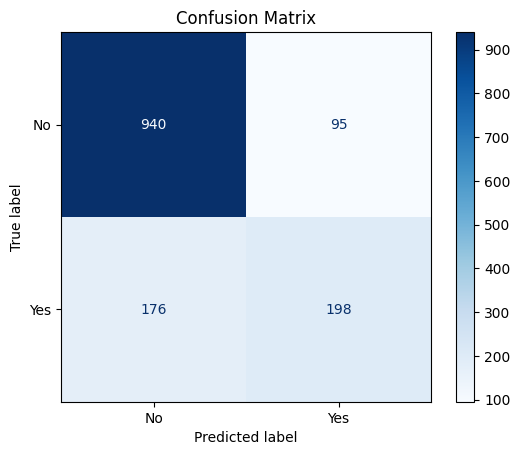

In [15]:
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretación

La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de los clientes que permanecen en la compañía, identificando **940 verdaderos negativos** frente a **95 falsos positivos**.

En cuanto a los clientes que finalmente abandonan el servicio, el modelo detecta correctamente **198 casos**, mientras que **176 clientes con riesgo de abandono no son identificados**, constituyendo la principal fuente de error del modelo.

Desde una perspectiva de negocio, los **falsos negativos** representan el escenario más costoso, ya que corresponden a clientes que abandonan la compañía sin haber sido detectados previamente. Esto implica la pérdida de oportunidades para aplicar estrategias de retención.

Por el contrario, los **falsos positivos** implican contactar con clientes que finalmente no iban a abandonar el servicio. Aunque este tipo de error supone un coste asociado a campañas de fidelización innecesarias, suele tener un impacto económico menor que la pérdida efectiva de un cliente.

En conjunto, el modelo muestra un buen equilibrio entre la detección de clientes en riesgo y la minimización de falsas alarmas, aunque todavía existe margen de mejora para incrementar la capacidad de identificación de clientes con riesgo de abandono.

## 4.4 Curva ROC

La curva ROC (**Receiver Operating Characteristic**) permite evaluar la capacidad del modelo para distinguir entre las dos clases del problema a diferentes umbrales de clasificación.

A diferencia de métricas como la Accuracy, la curva ROC no depende de un único umbral de decisión, proporcionando una visión más completa del comportamiento del modelo.

El área bajo la curva (**ROC-AUC**) resume esta capacidad discriminativa mediante un único valor comprendido entre 0 y 1.

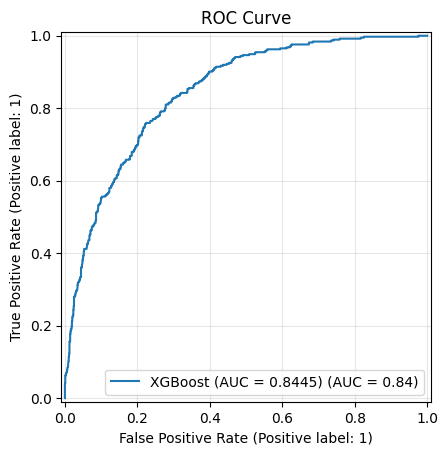

In [17]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob):.4f})"
)

plt.title("ROC Curve")
plt.grid(alpha=0.3)

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretación

La curva ROC representa la capacidad del modelo para distinguir entre clientes que abandonan el servicio y clientes que permanecen en la compañía a medida que varía el umbral de clasificación.

El modelo obtiene un **ROC-AUC de 0.8445**, lo que indica una buena capacidad discriminativa. En términos generales, este resultado significa que existe aproximadamente un **84 % de probabilidad** de que el modelo asigne una mayor probabilidad de abandono a un cliente que realmente abandona que a otro que finalmente permanece en la compañía.

La forma de la curva, claramente alejada de la diagonal, confirma que el modelo ofrece un rendimiento significativamente superior al de una clasificación aleatoria.

Aunque todavía existe margen de mejora, el valor obtenido refleja que el modelo es capaz de separar de forma consistente ambas clases y constituye una herramienta útil para apoyar estrategias de retención de clientes.

# 5. Interpretación del modelo

## Objetivo

Una vez evaluado el rendimiento del modelo, el siguiente paso consiste en interpretar cuáles son las variables que más influyen en sus predicciones.

Este análisis permite comprender qué factores están más relacionados con el abandono de clientes y facilita la identificación de posibles acciones de negocio orientadas a mejorar la retención.

## 5.1 Importancia de variables

In [13]:
# Importancia de las variables

importancias = pd.Series(
    modelo_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importancias.head(15)

categoricas__Tipo_Contrato_Month-to-month     0.540742
categoricas__Servicio_Internet_Fiber optic    0.114337
categoricas__Soporte_Tecnico_No               0.070329
categoricas__Seguridad_Online_No              0.044352
categoricas__Metodo_Pago_Electronic check     0.030352
categoricas__Streaming_Peliculas_Yes          0.020939
categoricas__Streaming_TV_No                  0.020304
numericas__Antiguedad_Meses                   0.019192
categoricas__Tipo_Contrato_One year           0.015827
categoricas__Tipo_Contrato_Two year           0.014938
categoricas__Factura_Electronica_No           0.013823
categoricas__Copia_Seguridad_Online_No        0.010283
categoricas__Multiples_Lineas_No              0.010060
numericas__Cargo_Mensual                      0.007692
numericas__Cargos_Totales                     0.007521
dtype: float32

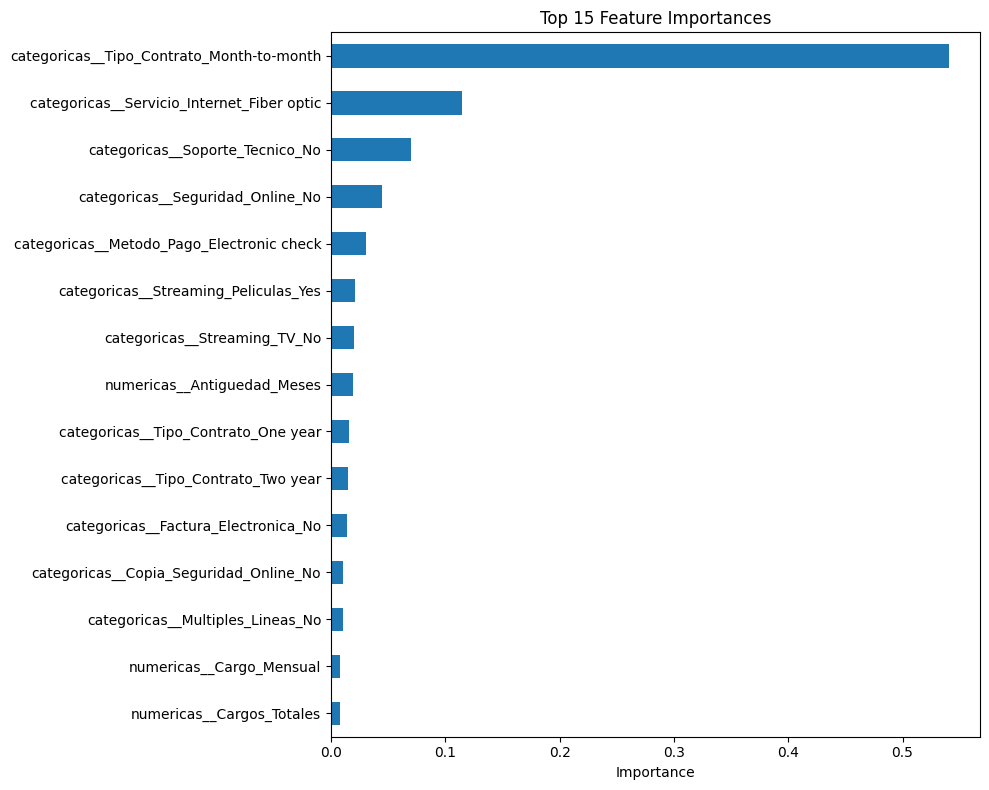

In [18]:
plt.figure(figsize=(10,8))

importancias.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances")

plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretación

El análisis de importancia de variables permite identificar cuáles son los factores que el modelo considera más relevantes para predecir el abandono de clientes.

La variable con mayor influencia es **el tipo de contrato mensual (Month-to-month)**, muy por encima del resto. Este resultado es coherente con el análisis exploratorio realizado previamente, donde se observó que los clientes con contratos mensuales presentaban una mayor tasa de abandono que aquellos con contratos de mayor duración.

Entre las variables más relevantes también aparecen el **servicio de Internet por fibra óptica**, la **ausencia de soporte técnico**, la **falta de seguridad online** y el **método de pago mediante Electronic Check**. Todas ellas ya habían mostrado una relación importante con el abandono durante el análisis exploratorio, lo que aporta consistencia a los resultados obtenidos por el modelo.

Asimismo, la **antigüedad del cliente** continúa siendo una variable relevante, indicando que el tiempo de permanencia constituye un factor importante para explicar el riesgo de abandono.

Es importante señalar que la importancia de variables refleja la relevancia de cada característica en las decisiones del modelo, pero no indica por sí misma si una variable incrementa o reduce la probabilidad de abandono. Para interpretar esa relación es necesario combinar estos resultados con el análisis exploratorio realizado anteriormente.

## 5.2 Análisis de las variables más relevantes

A partir de la importancia de variables obtenida por el modelo, se analizan los principales factores asociados al abandono de clientes y sus posibles implicaciones desde el punto de vista del negocio.

Este análisis permite transformar los resultados del modelo en información útil para apoyar la toma de decisiones y el diseño de estrategias de fidelización.

### Tipo de contrato mensual (Month-to-month)

El tipo de contrato mensual es, con diferencia, la variable más importante para el modelo.

Este resultado coincide con el análisis exploratorio realizado anteriormente y sugiere que los clientes con contratos de corta duración presentan un mayor riesgo de abandono, probablemente debido a la ausencia de compromisos de permanencia.

**Posible acción de negocio**

- Diseñar campañas para incentivar la migración hacia contratos de uno o dos años.
- Ofrecer descuentos o beneficios exclusivos por permanencia.

### Servicio de Internet por fibra óptica

La contratación del servicio de fibra óptica aparece como uno de los factores más relevantes para el modelo.

Este resultado podría estar relacionado con expectativas más elevadas por parte de estos clientes o con posibles incidencias en la calidad del servicio.

**Posible acción de negocio**

- Analizar la satisfacción de los clientes con fibra óptica.
- Revisar incidencias técnicas y tiempos de resolución.
- Priorizar acciones de fidelización en este segmento.

### Ausencia de soporte técnico

Los clientes que no disponen de soporte técnico presentan una mayor relevancia dentro del modelo predictivo.

Esto puede indicar que los servicios de asistencia contribuyen a mejorar la experiencia del cliente y reducir la probabilidad de abandono.

**Posible acción de negocio**

- Promover la contratación de servicios de soporte técnico.
- Ofrecer periodos de prueba gratuitos.

### Falta de seguridad online

La ausencia de servicios de seguridad online también aparece entre las variables más importantes.

Este resultado puede reflejar un menor grado de vinculación del cliente con la compañía, al disponer de menos servicios adicionales.

**Posible acción de negocio**

- Incentivar la contratación de servicios complementarios.
- Diseñar paquetes que aumenten el valor percibido por el cliente.

### Método de pago mediante Electronic Check

El uso de Electronic Check aparece asociado a una mayor relevancia en la predicción del abandono.

Aunque el modelo no permite establecer relaciones causales, este resultado sugiere que determinados perfiles de clientes pueden concentrarse en este método de pago.

**Posible acción de negocio**

- Analizar las características de estos clientes.
- Promover métodos de pago automáticos que favorezcan una mayor fidelización.

# 6. Implicaciones de negocio

## Objetivo

Los resultados obtenidos mediante el modelo predictivo permiten identificar patrones asociados al abandono de clientes y constituyen una herramienta de apoyo para la toma de decisiones.

En este apartado se presentan algunas posibles aplicaciones del modelo desde una perspectiva empresarial, orientadas a mejorar la retención de clientes y optimizar la asignación de recursos.

### Estrategias de retención

A partir de los resultados obtenidos, pueden plantearse diversas acciones orientadas a reducir la tasa de abandono de clientes.

**1. Priorizar clientes con contratos mensuales**

El modelo identifica el contrato **Month-to-month** como el principal factor asociado al abandono. La empresa podría desarrollar campañas específicas para incentivar la migración hacia contratos de mayor duración mediante descuentos, promociones o beneficios exclusivos.

---

**2. Reforzar los servicios de valor añadido**

Variables como la ausencia de soporte técnico o de servicios de seguridad online aparecen entre las más relevantes para el modelo. Esto sugiere que ofrecer servicios complementarios puede aumentar el grado de vinculación del cliente con la compañía.

---

**3. Mejorar la experiencia de los clientes con fibra óptica**

El servicio de Internet por fibra óptica constituye otro de los factores destacados por el modelo. Resulta recomendable analizar posibles incidencias, tiempos de resolución y niveles de satisfacción de este segmento de clientes para identificar oportunidades de mejora.

---

**4. Diseñar campañas de retención más eficientes**

El modelo permite estimar el riesgo de abandono de cada cliente antes de que se produzca la baja. Esta información puede utilizarse para dirigir las campañas de fidelización únicamente a los clientes con mayor probabilidad de abandono, optimizando así los recursos comerciales.

---

**5. Apoyar la toma de decisiones basada en datos**

Más allá de la predicción individual, el modelo proporciona información valiosa sobre los factores asociados al abandono, facilitando la definición de estrategias comerciales, el diseño de nuevos productos y la planificación de acciones de fidelización.

# 7. Limitaciones del proyecto

## Objetivo

Como cualquier modelo de Machine Learning, los resultados obtenidos deben interpretarse teniendo en cuenta las limitaciones del conjunto de datos, de la metodología empleada y del propio modelo.

Identificar estas limitaciones permite comprender mejor el alcance del proyecto y establecer posibles líneas de mejora para futuros desarrollos.

### Limitaciones identificadas

Aunque el modelo seleccionado ofrece un buen rendimiento general, existen diversos aspectos que podrían mejorarse en futuras versiones del proyecto.

**1. Desbalance de clases**

El conjunto de datos presenta un mayor número de clientes que permanecen en la compañía que de clientes que abandonan el servicio. Esta diferencia dificulta la identificación de la clase minoritaria y explica, en parte, el menor valor obtenido en Recall.

---

**2. Información disponible**

El modelo únicamente utiliza las variables incluidas en el conjunto de datos. Factores adicionales como reclamaciones recientes, calidad del servicio, historial de incidencias, interacciones con atención al cliente o campañas comerciales podrían aportar información relevante para mejorar la capacidad predictiva.

---

**3. Interpretabilidad del modelo**

Aunque XGBoost proporciona un excelente rendimiento, su funcionamiento interno resulta más complejo de interpretar que modelos más sencillos como la Regresión Logística.

Por este motivo, la importancia de variables debe entenderse como una medida de relevancia para el modelo y no como una relación causal entre las variables y el abandono.

---

**4. Ajuste del umbral de clasificación**

En este proyecto se ha utilizado el umbral de clasificación por defecto (0.5).

En un entorno empresarial, dicho umbral podría ajustarse para priorizar la detección de clientes con riesgo de abandono, aumentando el Recall incluso a costa de incrementar el número de falsos positivos.

---

**5. Actualización del modelo**

Los patrones de comportamiento de los clientes pueden cambiar con el tiempo.

Por ello, sería recomendable reentrenar periódicamente el modelo utilizando información más reciente para mantener su capacidad predictiva.

# 8. Conclusiones finales

## Conclusiones finales

En este proyecto se ha desarrollado un modelo de Machine Learning para la predicción del abandono de clientes en una empresa de telecomunicaciones, siguiendo un flujo de trabajo completo que abarca desde la comprensión del problema de negocio hasta la interpretación de los resultados obtenidos.

El proceso comenzó con la preparación y limpieza de los datos, continuó con el análisis exploratorio y el preprocesamiento de las variables, y posteriormente se evaluaron distintos algoritmos de clasificación. Tras la optimización de hiperparámetros mediante **GridSearchCV** y validación cruzada, **XGBoost** fue seleccionado como el modelo con mejor rendimiento global.

La evaluación del modelo mostró una buena capacidad para distinguir entre clientes que permanecen y clientes que abandonan el servicio, alcanzando un **ROC-AUC de 0.8445** y un equilibrio adecuado entre precisión y capacidad predictiva.

El análisis de la importancia de variables confirmó que factores como el **tipo de contrato**, el **servicio de Internet por fibra óptica**, la **ausencia de soporte técnico**, la **falta de servicios de seguridad online** y el **método de pago** desempeñan un papel relevante en la predicción del abandono.

Desde una perspectiva empresarial, el proyecto demuestra cómo las técnicas de Machine Learning pueden utilizarse para identificar clientes con mayor riesgo de abandono y apoyar el diseño de estrategias de fidelización más eficientes.

No obstante, la elección del modelo debe realizarse siempre teniendo en cuenta el objetivo de negocio. Aunque **XGBoost** ofrece el mejor rendimiento global, modelos como la **Regresión Logística** pueden resultar preferibles en escenarios donde la prioridad sea maximizar la detección de clientes con riesgo de abandono mediante un mayor Recall.

En conjunto, este proyecto pone de manifiesto la importancia de combinar el análisis de datos, la optimización de modelos y la interpretación de resultados para transformar los datos en información útil que facilite la toma de decisiones basada en evidencia.